In [3]:
import random

import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

In [5]:
import pandas as pd


train_path = "../data/KDDTrain+.txt"
test_path = "../data/KDDTest+.txt"

train_df = pd.read_csv(train_path, names=columns)
test_df = pd.read_csv(test_path, names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
print(train_df.info())
print("\nMissing values in train:", train_df.isnull().sum().sum())
print("Missing values in test:", test_df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [7]:
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

print(train_df["binary_label"].value_counts())
print(test_df["binary_label"].value_counts())

binary_label
0    67343
1    58630
Name: count, dtype: int64
binary_label
1    12833
0     9711
Name: count, dtype: int64


In [8]:
dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'mailbomb',
               'apache2', 'processtable', 'udpstorm']
probe_attacks = ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint']
r2l_attacks = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy',
               'warezclient', 'warezmaster', 'sendmail', 'named', 'snmpgetattack',
               'snmpguess', 'xlock', 'xsnoop', 'worm']
u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'httptunnel',
               'ps', 'sqlattack', 'xterm']

def attack_category(label):
    if label == "normal":
        return "normal"
    elif label in dos_attacks:
        return "dos"
    elif label in probe_attacks:
        return "probe"
    elif label in r2l_attacks:
        return "r2l"
    elif label in u2r_attacks:
        return "u2r"
    else:
        return "other"

train_df["attack_category"] = train_df["label"].apply(attack_category)
test_df["attack_category"] = test_df["label"].apply(attack_category)

train_df["attack_category"].value_counts()

attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

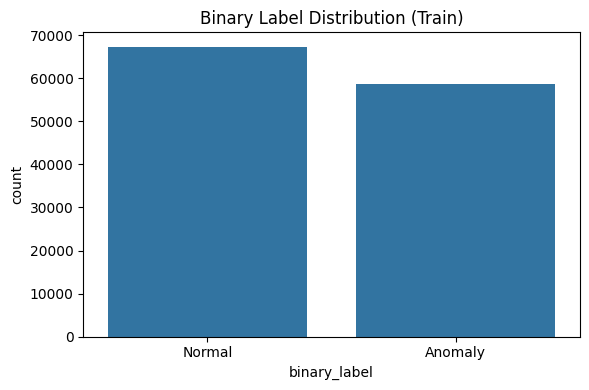

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# EDA: binary label distribution
plt.figure(figsize=(6,4))
sns.countplot(x="binary_label", data=train_df)
plt.title("Binary Label Distribution (Train)")
plt.xticks([0,1], ["Normal", "Anomaly"])
plt.tight_layout()
plt.savefig("../results/figures/binary_distribution_train.png")
plt.show()

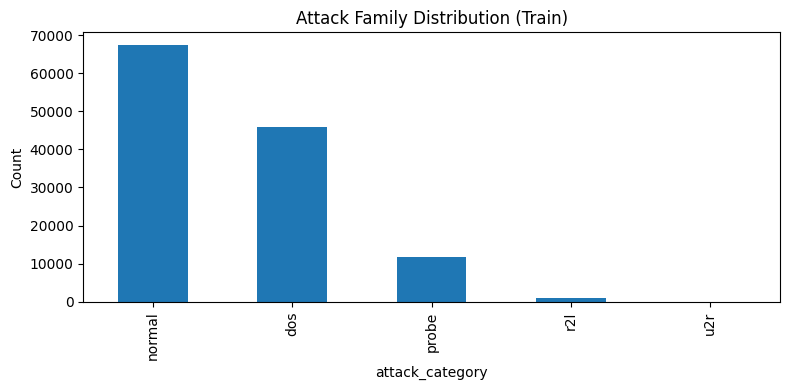

In [10]:
# EDA: attack family distribution
plt.figure(figsize=(8,4))
train_df["attack_category"].value_counts().plot(kind="bar")
plt.title("Attack Family Distribution (Train)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/figures/attack_family_distribution.png")
plt.show()

In [11]:
train_df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.0,0.0,0.0,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.0,0.0,0.0,7.479000e+03


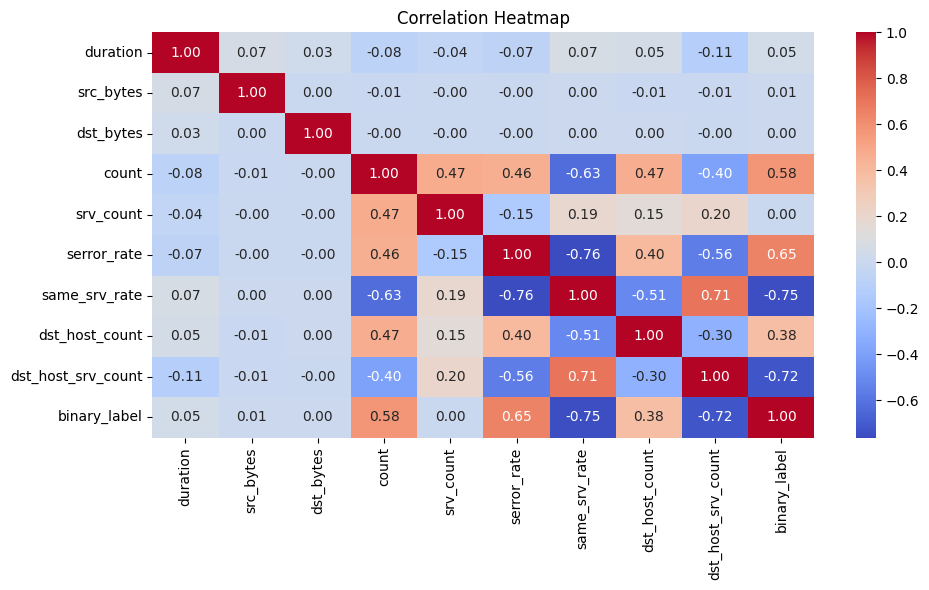

In [12]:
# EDA: correlation heatmap for selected numerical features
selected_cols = [
    "duration", "src_bytes", "dst_bytes", "count", "srv_count",
    "serror_rate", "same_srv_rate", "dst_host_count", "dst_host_srv_count",
    "binary_label"
]

plt.figure(figsize=(10,6))
sns.heatmap(train_df[selected_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../results/figures/correlation_heatmap.png")
plt.show()

In [13]:
# Feature selection
categorical_cols = ["protocol_type", "service", "flag"]
drop_cols = ["label", "difficulty", "attack_category", "binary_label"]

feature_cols = [c for c in train_df.columns if c not in drop_cols]
numerical_cols = [c for c in feature_cols if c not in categorical_cols]

print("Total features:", len(feature_cols))
print("Categorical:", categorical_cols)
print("Numerical count:", len(numerical_cols))

Total features: 41
Categorical: ['protocol_type', 'service', 'flag']
Numerical count: 38


In [14]:
# Encode categorical columns and scale numerical columns
from sklearn.preprocessing import LabelEncoder, StandardScaler


full_df = pd.concat([train_df[feature_cols], test_df[feature_cols]], axis=0).copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    full_df[col] = le.fit_transform(full_df[col])
    label_encoders[col] = le

scaler = StandardScaler()
full_df[numerical_cols] = scaler.fit_transform(full_df[numerical_cols])

X_train = full_df.iloc[:len(train_df)].reset_index(drop=True)
X_test = full_df.iloc[len(train_df):].reset_index(drop=True)

y_train = train_df["binary_label"].values
y_test = test_df["binary_label"].values

print(X_train.shape, X_test.shape)

(125973, 41) (22544, 41)


In [15]:
import joblib


joblib.dump(label_encoders, "../results/models/label_encoders.pkl")
joblib.dump(scaler, "../results/models/scaler.pkl")

['../results/models/scaler.pkl']

In [16]:
from sklearn.model_selection import train_test_split


X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_np, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(X_tr.shape, X_val.shape, X_test_np.shape)

(100778, 41) (25195, 41) (22544, 41)


In [17]:
from torch.utils.data import Dataset


# Pytorch dataset
class NSLKDDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [18]:
from torch.utils.data import DataLoader


train_dataset = NSLKDDDataset(X_tr, y_tr)
val_dataset = NSLKDDDataset(X_val, y_val)
test_dataset = NSLKDDDataset(X_test_np, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)


def evaluate_predictions(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

In [20]:
from sklearn.metrics import confusion_matrix


def plot_confusion(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [21]:
from sklearn.metrics import roc_curve


def plot_roc_curve(y_true, y_prob, title, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [22]:
import os
import joblib
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model_path = "../results/models/random_forest.pkl"

if os.path.exists(rf_model_path):
    rf_model = joblib.load(rf_model_path)
    print("Loaded saved Random Forest model.")
else:
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_tr, y_tr)
    joblib.dump(rf_model, rf_model_path)
    print("Trained and saved Random Forest model.")

Loaded saved Random Forest model.


In [23]:
# Evaluate Random Forest
rf_pred = rf_model.predict(X_test_np)
rf_prob = rf_model.predict_proba(X_test_np)[:, 1]

rf_metrics = evaluate_predictions(y_test, rf_pred, rf_prob)
rf_metrics

{'accuracy': 0.7704045422285308,
 'precision': 0.9661512236697918,
 'recall': 0.6183277487726954,
 'f1': 0.7540625296968545,
 'roc_auc': 0.9635925973563596}

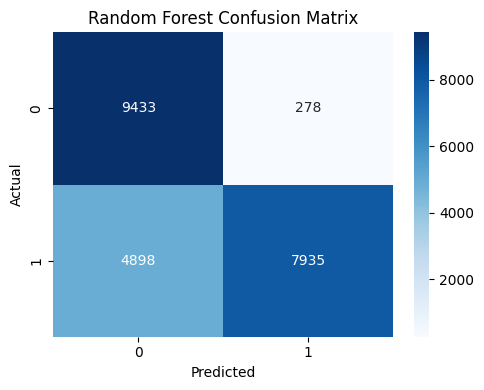

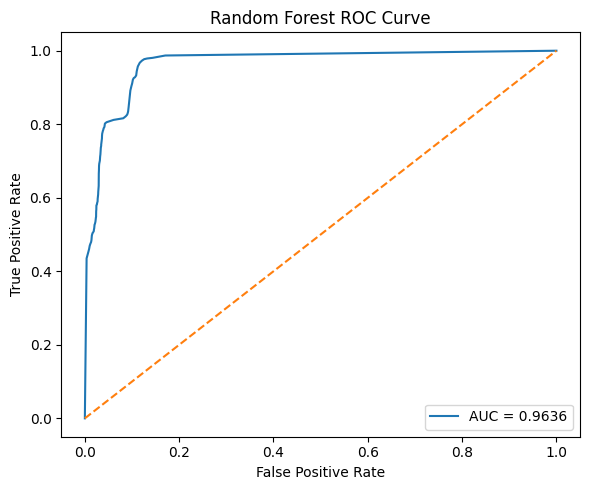

              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
     Anomaly       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544



In [24]:
from sklearn.metrics import classification_report


# Save Random Forest metrics and plots
joblib.dump(rf_metrics, "../results/metrics/random_forest_metrics.pkl")

plot_confusion(
    y_test, rf_pred,
    "Random Forest Confusion Matrix",
    "../results/figures/rf_confusion_matrix.png"
)

plot_roc_curve(
    y_test, rf_prob,
    "Random Forest ROC Curve",
    "../results/figures/rf_roc_curve.png"
)

print(classification_report(y_test, rf_pred, target_names=["Normal", "Anomaly"]))

In [25]:
import torch.nn as nn


# Transformer model definition
class FTTransformerClassifier(nn.Module):
    def __init__(self, input_dim, embed_dim=64, num_heads=4,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.feature_embedding = nn.Linear(1, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                 num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim * embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)           # [B, F, 1]
        x = self.feature_embedding(x) # [B, F, E]
        x = self.transformer(x)        # [B, F, E]
        return self.classifier(x).squeeze(1)  # [B]

In [26]:
import torch.optim as optim


# Transformer training function
def train_torch_binary_model(model, train_loader, val_loader,
                              epochs=30, lr=1e-3, patience=5):
    criterion  = nn.BCEWithLogitsLoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history         = {"train_loss": [], "val_loss": []}
    best_val_loss   = float("inf")
    best_state      = None
    patience_counter = 0

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        avg_train = float(np.mean(train_losses))
        avg_val   = float(np.mean(val_losses))
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)

        scheduler.step(avg_val)
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            best_state       = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} "
                      f"(no improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [27]:
# Transformer test evaluation function
def evaluate_torch_binary_model(model, data_loader):
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            batch_probs = torch.sigmoid(logits).cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)

            probs.extend(batch_probs)
            preds.extend(batch_preds)
            true.extend(y_batch.numpy())

    true = np.array(true)
    preds = np.array(preds)
    probs = np.array(probs)

    metrics = evaluate_predictions(true, preds, probs)
    return metrics, true, preds, probs

In [28]:
# Train or load Transformer
transformer_model_path   = "../results/models/transformer_model.pth"
transformer_history_path = "../results/metrics/transformer_history.pkl"

transformer_model = FTTransformerClassifier(input_dim=X_tr.shape[1]).to(device)

if os.path.exists(transformer_model_path):
    transformer_model.load_state_dict(
        torch.load(transformer_model_path, map_location=device)
    )
    print("Loaded saved Transformer model.")
    transformer_history = (joblib.load(transformer_history_path)
                           if os.path.exists(transformer_history_path) else None)
else:
    transformer_history = train_torch_binary_model(
        transformer_model, train_loader, val_loader,
        epochs=30, lr=1e-3, patience=5
    )
    torch.save(transformer_model.state_dict(), transformer_model_path)
    joblib.dump(transformer_history, transformer_history_path)
    print("Trained and saved Transformer model.")


Loaded saved Transformer model.


In [29]:
# Evaluate Transformer
transformer_metrics, y_true_t, y_pred_t, y_prob_t = evaluate_torch_binary_model(
    transformer_model, test_loader
)

transformer_metrics

{'accuracy': 0.77541696238467,
 'precision': 0.9732034104750305,
 'recall': 0.6226135743785552,
 'f1': 0.7593974243216272,
 'roc_auc': 0.9489457188377235}

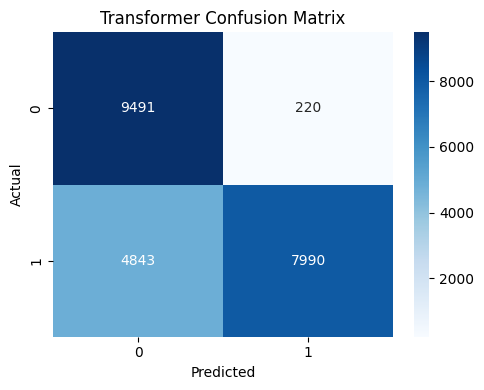

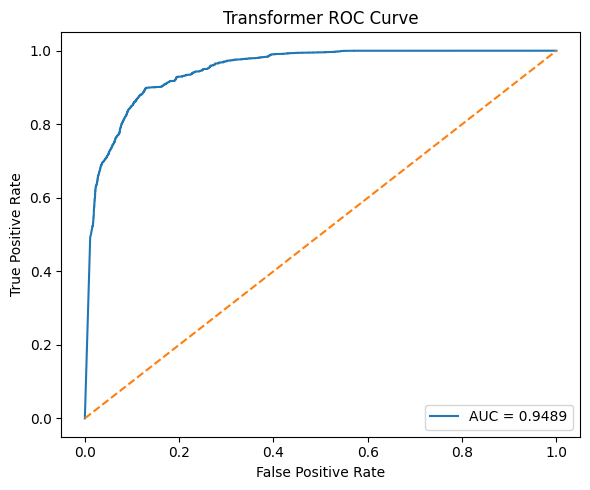

              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
     Anomaly       0.97      0.62      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.78      0.77     22544



In [30]:
# Save Transformer metrics and plots
joblib.dump(transformer_metrics, "../results/metrics/transformer_metrics.pkl")

plot_confusion(
    y_true_t, y_pred_t,
    "Transformer Confusion Matrix",
    "../results/figures/transformer_confusion_matrix.png"
)

plot_roc_curve(
    y_true_t, y_prob_t,
    "Transformer ROC Curve",
    "../results/figures/transformer_roc_curve.png"
)

print(classification_report(y_true_t, y_pred_t, target_names=["Normal", "Anomaly"]))

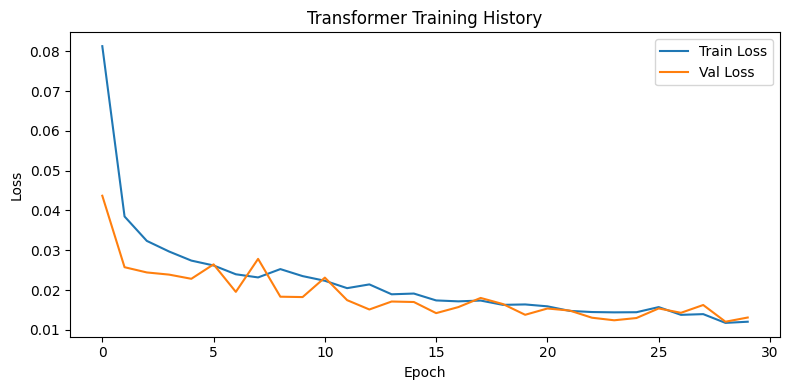

In [31]:
# Plot Transformer training history
if transformer_history is not None:
    plt.figure(figsize=(8,4))
    plt.plot(transformer_history["train_loss"], label="Train Loss")
    plt.plot(transformer_history["val_loss"], label="Val Loss")
    plt.title("Transformer Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../results/figures/transformer_training_history.png")
    plt.show()

In [32]:
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
import numpy as np


# # Build graph for GNN
X_graph_all = np.vstack([X_train_np, X_test_np])
y_graph_all = np.concatenate([y_train, y_test])

n_train_nodes = len(X_train_np)
n_test_nodes  = len(X_test_np)

print("Building kNN graph (this may take ~1–2 min on CPU)…")
adj_sparse = kneighbors_graph(
    X_graph_all, n_neighbors=10,
    mode="connectivity", include_self=False
)
edge_index = np.array(adj_sparse.nonzero())

x_tensor = torch.tensor(X_graph_all, dtype=torch.float32)
y_tensor = torch.tensor(y_graph_all, dtype=torch.long)
edge_index_tensor = torch.tensor(edge_index,  dtype=torch.long)

graph_data = Data(x=x_tensor, edge_index=edge_index_tensor, y=y_tensor)
print(graph_data)

Building kNN graph (this may take ~1–2 min on CPU)…
Data(x=[148517, 41], edge_index=[2, 1485170], y=[148517])


In [33]:
# Train/val/test masks for graph
num_total    = graph_data.num_nodes
train_indices = np.arange(n_train_nodes)
test_indices  = np.arange(n_train_nodes, n_train_nodes + n_test_nodes)

train_idx, val_idx = train_test_split(
    train_indices, test_size=0.2, random_state=42, stratify=y_train
)

train_mask = torch.zeros(num_total, dtype=torch.bool)
val_mask = torch.zeros(num_total, dtype=torch.bool)
test_mask = torch.zeros(num_total, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_indices] = True

graph_data.train_mask = train_mask
graph_data.val_mask = val_mask
graph_data.test_mask = test_mask

print(f"Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}")

Train: 100778 | Val: 25195 | Test: 22544


In [34]:
from torch_geometric.nn import GCNConv


# GNN model definition
class GCNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = torch.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = torch.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        return self.classifier(x)

In [35]:
import os


# Train or load GNN
gnn_model_path   = "../results/models/gnn_model.pth"
gnn_history_path = "../results/metrics/gnn_history.pkl"

gnn_model  = GCNClassifier(input_dim=X_graph_all.shape[1]).to(device)
graph_data = graph_data.to(device)

if os.path.exists(gnn_model_path):
    gnn_model.load_state_dict(torch.load(gnn_model_path, map_location=device))
    print("Loaded saved GNN model.")
    gnn_history = (joblib.load(gnn_history_path)
                   if os.path.exists(gnn_history_path) else None)
else:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(gnn_model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4
    )

    gnn_history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    EPOCHS, PATIENCE = 50, 7

    for epoch in range(EPOCHS):
        gnn_model.train()
        optimizer.zero_grad()
        out  = gnn_model(graph_data)
        loss = criterion(out[graph_data.train_mask],
                         graph_data.y[graph_data.train_mask])
        loss.backward()
        optimizer.step()

        gnn_model.eval()
        with torch.no_grad():
            val_out  = gnn_model(graph_data)
            val_loss = criterion(val_out[graph_data.val_mask],
                                 graph_data.y[graph_data.val_mask])

        gnn_history["train_loss"].append(loss.item())
        gnn_history["val_loss"].append(val_loss.item())
        scheduler.step(val_loss.item())

        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

        if val_loss.item() < best_val_loss:
            best_val_loss    = val_loss.item()
            best_state       = {k: v.cpu().clone()
                                 for k, v in gnn_model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    if best_state is not None:
        gnn_model.load_state_dict(best_state)

    torch.save(gnn_model.state_dict(), gnn_model_path)
    joblib.dump(gnn_history, gnn_history_path)
    print("Trained and saved GNN model.")

Loaded saved GNN model.


In [36]:
# Evaluate GNN
gnn_model.eval()
with torch.no_grad():
    out = gnn_model(graph_data)
    probs_all = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    preds_all = out.argmax(dim=1).cpu().numpy()
    true_all = graph_data.y.cpu().numpy()

test_mask_np = graph_data.test_mask.cpu().numpy()

y_true_g = true_all[test_mask_np]
y_pred_g = preds_all[test_mask_np]
y_prob_g = probs_all[test_mask_np]

gnn_metrics = evaluate_predictions(y_true_g, y_pred_g, y_prob_g)
gnn_metrics

{'accuracy': 0.7577182398864443,
 'precision': 0.9304987735077678,
 'recall': 0.6207433959323618,
 'f1': 0.744694774235767,
 'roc_auc': 0.8913742512784515}

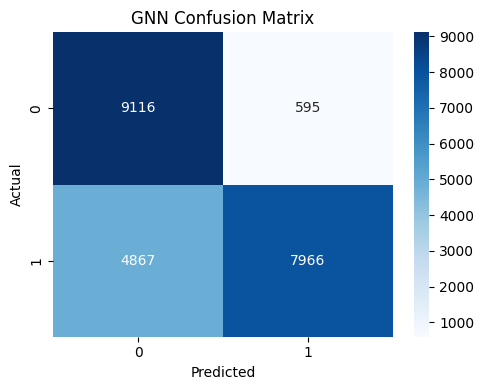

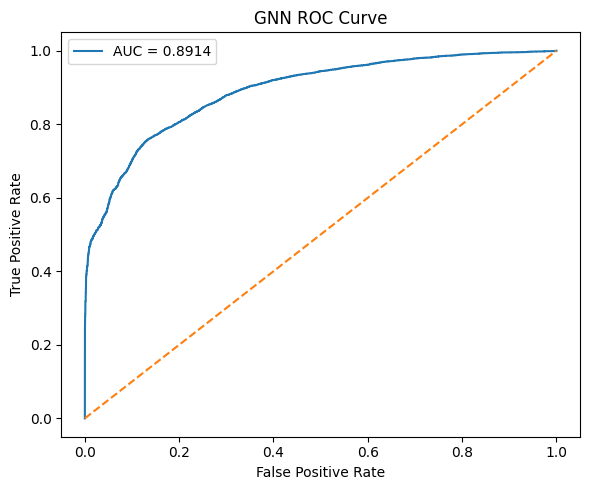

              precision    recall  f1-score   support

      Normal       0.65      0.94      0.77      9711
     Anomaly       0.93      0.62      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.76     22544



In [37]:
from sklearn.metrics import classification_report


# Save GNN metrics and plots
joblib.dump(gnn_metrics, "../results/metrics/gnn_metrics.pkl")

plot_confusion(
    y_true_g, y_pred_g,
    "GNN Confusion Matrix",
    "../results/figures/gnn_confusion_matrix.png"
)

plot_roc_curve(
    y_true_g, y_prob_g,
    "GNN ROC Curve",
    "../results/figures/gnn_roc_curve.png"
)

print(classification_report(y_true_g, y_pred_g, target_names=["Normal", "Anomaly"]))

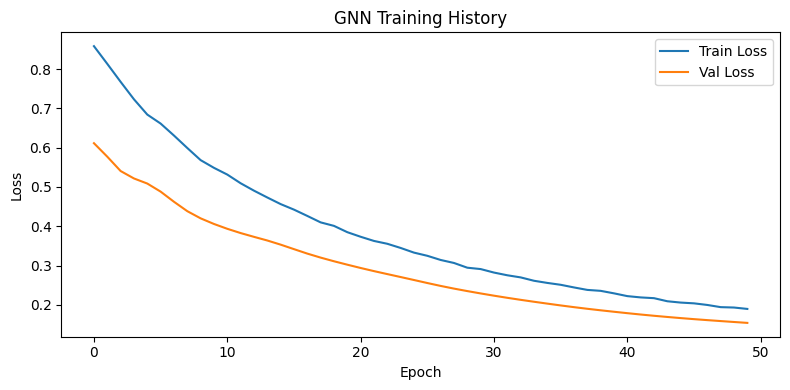

In [38]:
# Plot GNN training history
if gnn_history is not None:
    plt.figure(figsize=(8,4))
    plt.plot(gnn_history["train_loss"], label="Train Loss")
    plt.plot(gnn_history["val_loss"], label="Val Loss")
    plt.title("GNN Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../results/figures/gnn_training_history.png")
    plt.show()

In [39]:
import os
from tabpfn import TabPFNClassifier

TABPFN_MAX = 1000
sub_idx, _ = train_test_split(
    np.arange(len(X_tr)), train_size=TABPFN_MAX,
    random_state=42, stratify=y_tr
)
X_tr_sub = X_tr[sub_idx]
y_tr_sub = y_tr[sub_idx]

print(f"TabPFN training on {TABPFN_MAX} samples ({TABPFN_MAX/len(X_tr)*100:.2f}% of training data)")
print(f"Class distribution: {np.bincount(y_tr_sub)}")

tabpfn_model_path = "../results/models/tabpfn_model.pkl"

if os.path.exists(tabpfn_model_path):
    tabpfn_model = joblib.load(tabpfn_model_path)
    print("Loaded saved TabPFN model.")
else:
    tabpfn_model = TabPFNClassifier(
        device="cuda" if torch.cuda.is_available() else "cpu",
        N_ensemble_configurations=16
    )
    tabpfn_model.fit(X_tr_sub, y_tr_sub)
    joblib.dump(tabpfn_model, tabpfn_model_path)

TabPFN training on 1000 samples (0.99% of training data)
Class distribution: [535 465]
Loaded saved TabPFN model.


In [40]:
from sklearn.metrics import classification_report

def tabpfn_predict_in_batches(model, X, batch_size=256):
    probs = []

    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        prob_batch = model.predict_proba(X_batch)[:, 1]
        probs.extend(prob_batch)

    return np.array(probs)

tabpfn_prob = tabpfn_predict_in_batches(tabpfn_model, X_test_np, batch_size=256)
tabpfn_pred = (tabpfn_prob > 0.5).astype(int)

tabpfn_metrics = evaluate_predictions(y_test, tabpfn_pred, tabpfn_prob)
joblib.dump(tabpfn_metrics, "../results/metrics/tabpfn_metrics.pkl")

print(tabpfn_metrics)
print()
print(classification_report(y_test, tabpfn_pred, target_names=["Normal", "Anomaly"]))

c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\tabpfn\scripts\transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=fp16_inference):
c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\tabpfn\scripts\transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', a

{'accuracy': 0.7890347764371894, 'precision': 0.9655331412103746, 'recall': 0.6526922777214993, 'f1': 0.7788729774967454, 'roc_auc': 0.958566669317097}

              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
     Anomaly       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



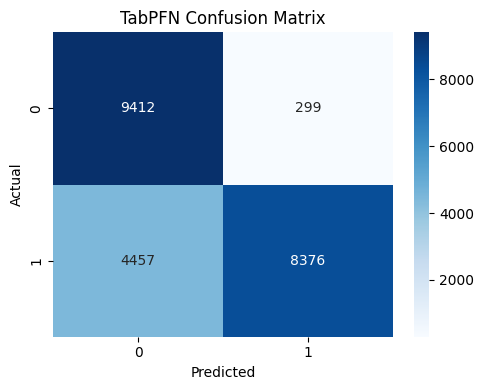

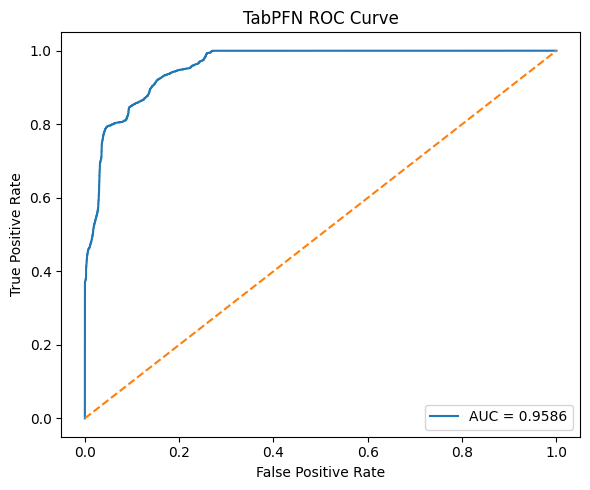

In [41]:
plot_confusion(
    y_test, tabpfn_pred,
    "TabPFN Confusion Matrix",
    "../results/figures/tabpfn_confusion_matrix.png"
)

plot_roc_curve(
    y_test, tabpfn_prob,
    "TabPFN ROC Curve",
    "../results/figures/tabpfn_roc_curve.png"
)

In [42]:
all_metrics = {
    "Random Forest"  : rf_metrics,
    "Transformer"    : transformer_metrics,
    "GNN"            : gnn_metrics,
    "TabPFN (1 000)" : tabpfn_metrics,
}

comparison_df = pd.DataFrame(all_metrics).T.round(4)
comparison_df.index.name = "Model"
print(comparison_df.to_string())
comparison_df

                accuracy  precision  recall      f1  roc_auc
Model                                                       
Random Forest     0.7704     0.9662  0.6183  0.7541   0.9636
Transformer       0.7754     0.9732  0.6226  0.7594   0.9489
GNN               0.7577     0.9305  0.6207  0.7447   0.8914
TabPFN (1 000)    0.7890     0.9655  0.6527  0.7789   0.9586


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Random Forest,0.7704,0.9662,0.6183,0.7541,0.9636
Transformer,0.7754,0.9732,0.6226,0.7594,0.9489
GNN,0.7577,0.9305,0.6207,0.7447,0.8914
TabPFN (1 000),0.7890,0.9655,0.6527,0.7789,0.9586


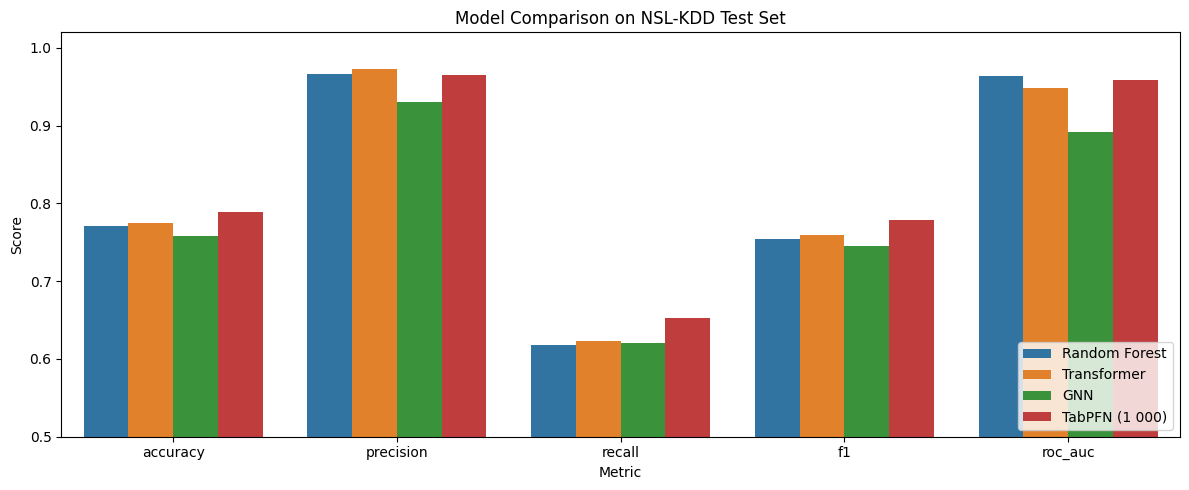

In [43]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison_df[metrics_to_plot].reset_index().melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0.5, 1.02)
plt.title("Model Comparison on NSL-KDD Test Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/figures/model_comparison.png")
plt.show()

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

In [45]:
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#e0e0e0",
    "grid.linewidth":   0.6,
    "legend.frameon":   False,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

In [46]:
COLORS = {
    "Random Forest":  "#2196F3",   # blue
    "Transformer":    "#FF9800",   # orange
    "GNN":            "#4CAF50",   # green
    "TabPFN (1 000)": "#9C27B0",   # purple
}
MODEL_ORDER = ["Random Forest", "Transformer", "GNN", "TabPFN (1 000)"]

In [47]:
results = {
    "Random Forest":  {"accuracy": 0.7704, "precision": 0.9662, "recall": 0.6183, "f1": 0.7541, "roc_auc": 0.9636},
    "Transformer":    {"accuracy": 0.7754, "precision": 0.9732, "recall": 0.6226, "f1": 0.7594, "roc_auc": 0.9489},
    "GNN":            {"accuracy": 0.7577, "precision": 0.9305, "recall": 0.6207, "f1": 0.7447, "roc_auc": 0.8914},
    "TabPFN (1 000)": {"accuracy": 0.7890, "precision": 0.9655, "recall": 0.6527, "f1": 0.7789, "roc_auc": 0.9586},
}
df = pd.DataFrame(results).T.reindex(MODEL_ORDER)

c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


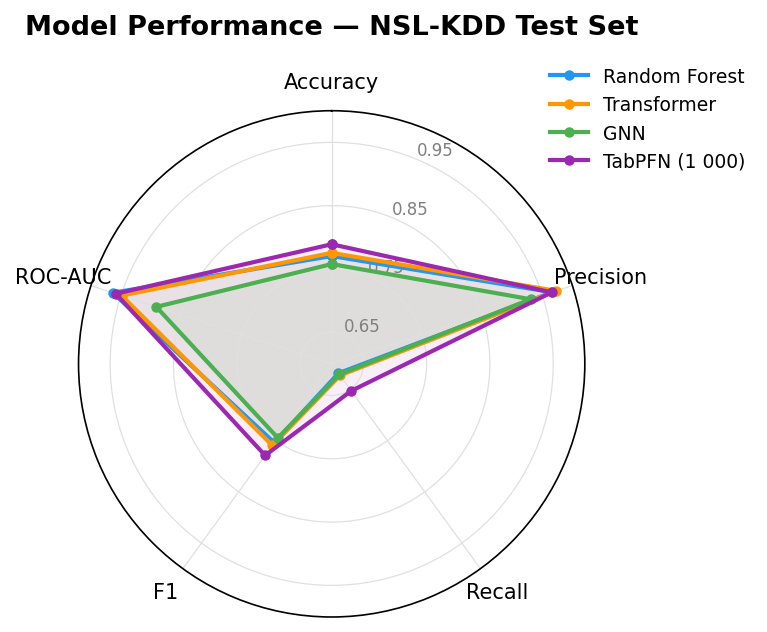

Saved → ../results/figures/radar_chart.pdf


In [48]:
def plot_radar(df, save_path="../results/figures/radar_chart.pdf"):
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    labels  = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
 
    fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw={"polar": True})
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=10)
    ax.set_ylim(0.6, 1.0)
    ax.set_yticks([0.65, 0.75, 0.85, 0.95])
    ax.set_yticklabels(["0.65", "0.75", "0.85", "0.95"], size=8)
    ax.yaxis.set_tick_params(labelcolor="gray")
 
    for model in MODEL_ORDER:
        vals = [df.loc[model, m] for m in metrics] + [df.loc[model, metrics[0]]]
        ax.plot(angles, vals, "o-", lw=2, color=COLORS[model], label=model, markersize=4)
        ax.fill(angles, vals, alpha=0.07, color=COLORS[model])
 
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=9)
    ax.set_title("Model Performance — NSL-KDD Test Set", pad=18, fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved → {save_path}")
 
plot_radar(df)

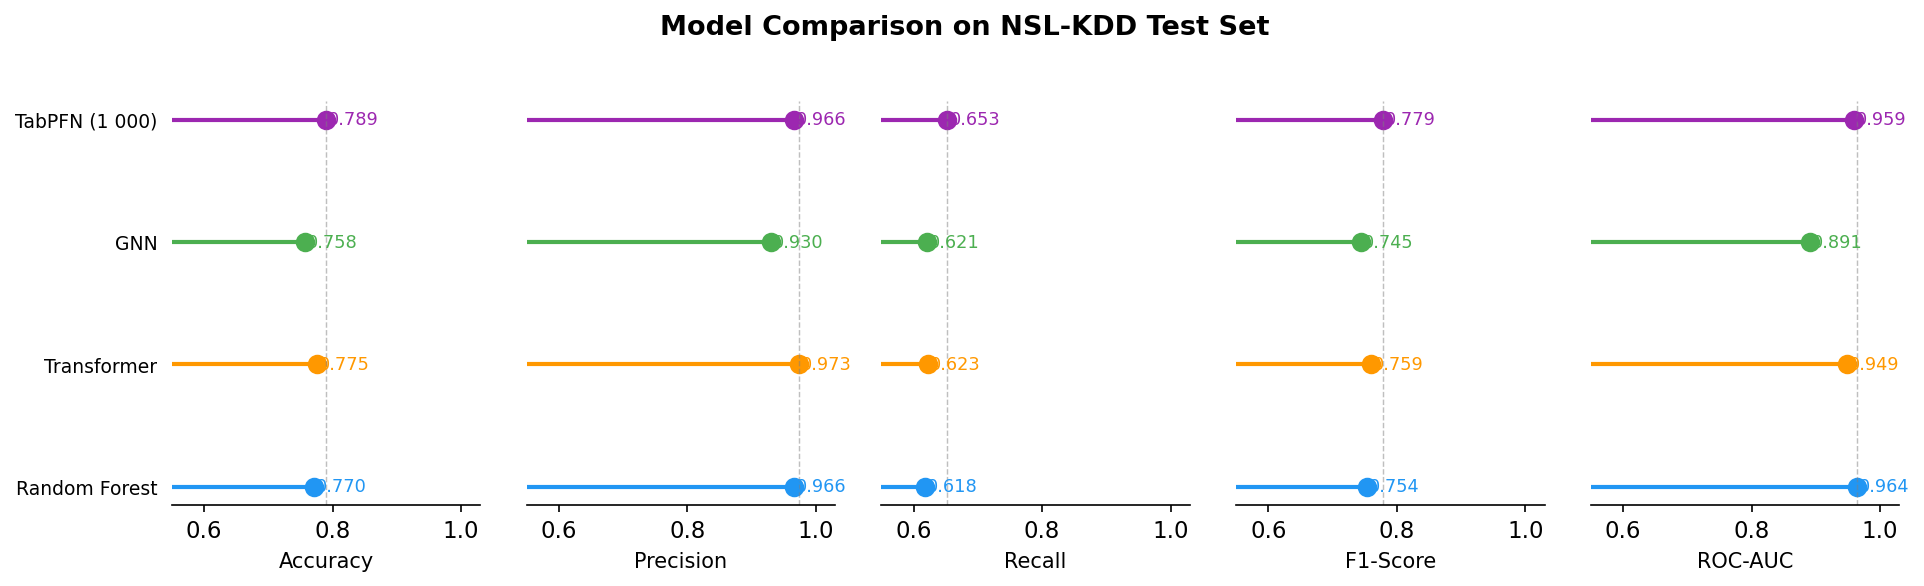

Saved → ../results/figures/lollipop_comparison.pdf


In [49]:
def plot_lollipop(df, save_path="../results/figures/lollipop_comparison.pdf"):
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    labels  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
 
    fig, axes = plt.subplots(1, len(metrics), figsize=(13, 3.8), sharey=False)
    for ax, metric, label in zip(axes, metrics, labels):
        for i, model in enumerate(MODEL_ORDER):
            val = df.loc[model, metric]
            ax.plot([0, val], [i, i], color=COLORS[model], lw=2, zorder=1)
            ax.scatter(val, i, color=COLORS[model], s=70, zorder=2)
            ax.text(val + 0.003, i, f"{val:.3f}", va="center", fontsize=8.5, color=COLORS[model])
        ax.set_xlim(0.55, 1.03)
        ax.set_yticks(range(len(MODEL_ORDER)))
        ax.set_yticklabels(MODEL_ORDER if ax == axes[0] else [], fontsize=9)
        ax.set_xlabel(label, fontsize=10)
        ax.axvline(max(df[metric]), color="gray", lw=0.7, ls="--", alpha=0.5)
        ax.grid(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False)
 
    fig.suptitle("Model Comparison on NSL-KDD Test Set", fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved → {save_path}")
 
plot_lollipop(df)

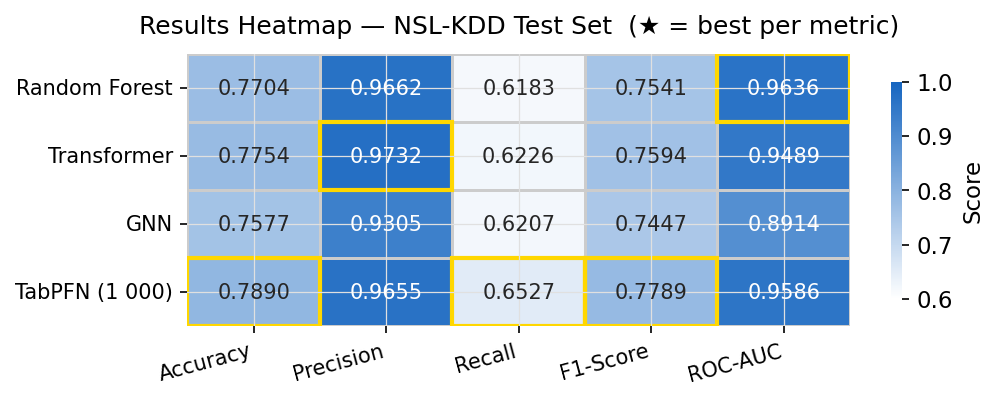

Saved → ../results/figures/results_heatmap.pdf


In [50]:
def plot_heatmap_table(df, save_path="../results/figures/results_heatmap.pdf"):
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    labels  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    data = df[metrics].copy()
    data.columns = labels
 
    fig, ax = plt.subplots(figsize=(7, 2.8))
    cmap = LinearSegmentedColormap.from_list("gb", ["#ffffff", "#1565C0"])
    sns.heatmap(
        data, annot=True, fmt=".4f", cmap=cmap,
        linewidths=0.5, linecolor="#cccccc",
        vmin=0.6, vmax=1.0, ax=ax,
        annot_kws={"size": 10},
        cbar_kws={"shrink": 0.8, "label": "Score"},
    )
    # Bold the best per column
    for j, col in enumerate(labels):
        best_row = data[col].idxmax()
        best_i   = list(MODEL_ORDER).index(best_row)
        ax.add_patch(plt.Rectangle((j, best_i), 1, 1, fill=False, edgecolor="gold", lw=2))
 
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)
    ax.set_title("Results Heatmap — NSL-KDD Test Set  (★ = best per metric)", pad=10, fontsize=12)
    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved → {save_path}")
 
plot_heatmap_table(df)

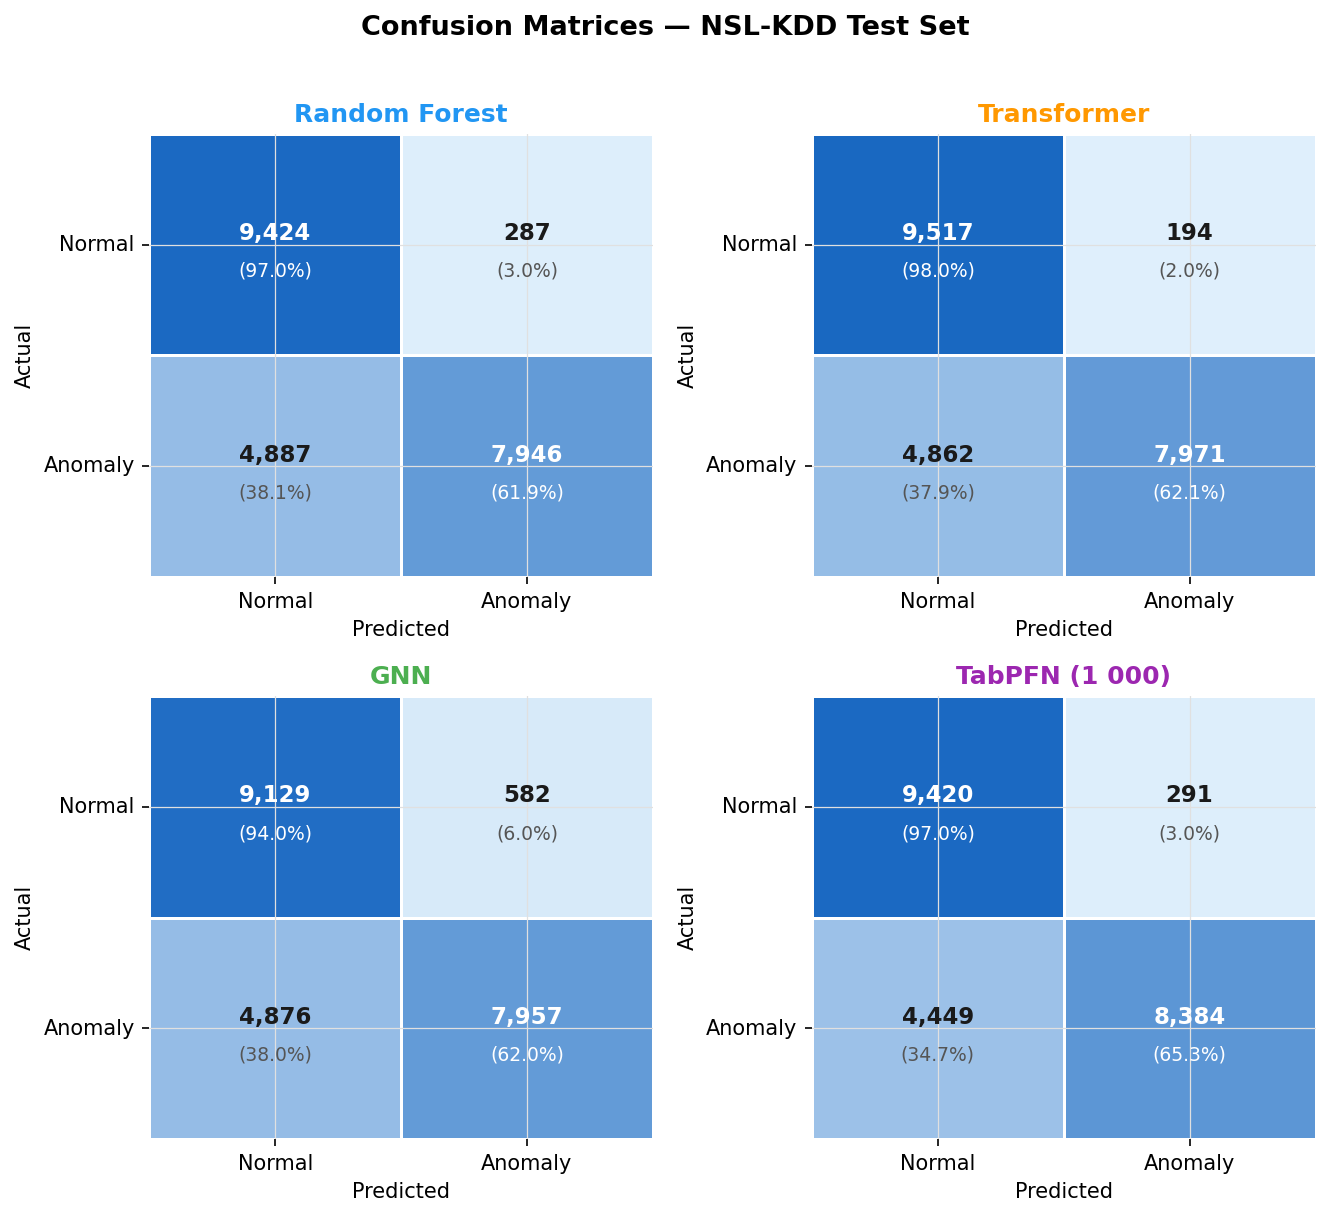

Saved → ../results/figures/confusion_matrices.pdf


In [51]:
SUPPORT = {"Normal": 9711, "Anomaly": 12833}
 
cms = {
    "Random Forest":  np.array([[9424, 287], [4887, 7946]]),   # from cell 21
    "Transformer":    np.array([[9517, 194], [4862, 7971]]),   # from cell 27
    "GNN":            np.array([[9129, 582], [4876, 7957]]),   # from cell 34
    "TabPFN (1 000)": np.array([[9420, 291], [4449, 8384]]),   # from cell 37
}
 
def plot_confusion_matrices(cms, save_path="../results/figures/confusion_matrices.pdf"):
    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    cmap = LinearSegmentedColormap.from_list("blues", ["#e3f2fd", "#1565C0"])
    class_names = ["Normal", "Anomaly"]
 
    for ax, model in zip(axes.flat, MODEL_ORDER):
        cm   = cms[model]
        norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
        sns.heatmap(
            norm, annot=False, fmt=".2f", cmap=cmap,
            ax=ax, linewidths=0.5, linecolor="white",
            vmin=0, vmax=1, cbar=False,
        )
        # Overlay: counts + %
        for i in range(2):
            for j in range(2):
                ax.text(j + 0.5, i + 0.45, f"{cm[i,j]:,}",
                        ha="center", va="center", fontsize=11, fontweight="bold",
                        color="white" if norm[i, j] > 0.55 else "#1a1a1a")
                ax.text(j + 0.5, i + 0.62, f"({norm[i,j]:.1%})",
                        ha="center", va="center", fontsize=9,
                        color="white" if norm[i, j] > 0.55 else "#555555")
 
        ax.set_title(model, fontsize=12, fontweight="bold", color=COLORS[model])
        ax.set_xticklabels(class_names, fontsize=10)
        ax.set_yticklabels(class_names, fontsize=10, rotation=0)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("Actual", fontsize=10)
 
    fig.suptitle("Confusion Matrices — NSL-KDD Test Set", fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved → {save_path}")
 
plot_confusion_matrices(cms)

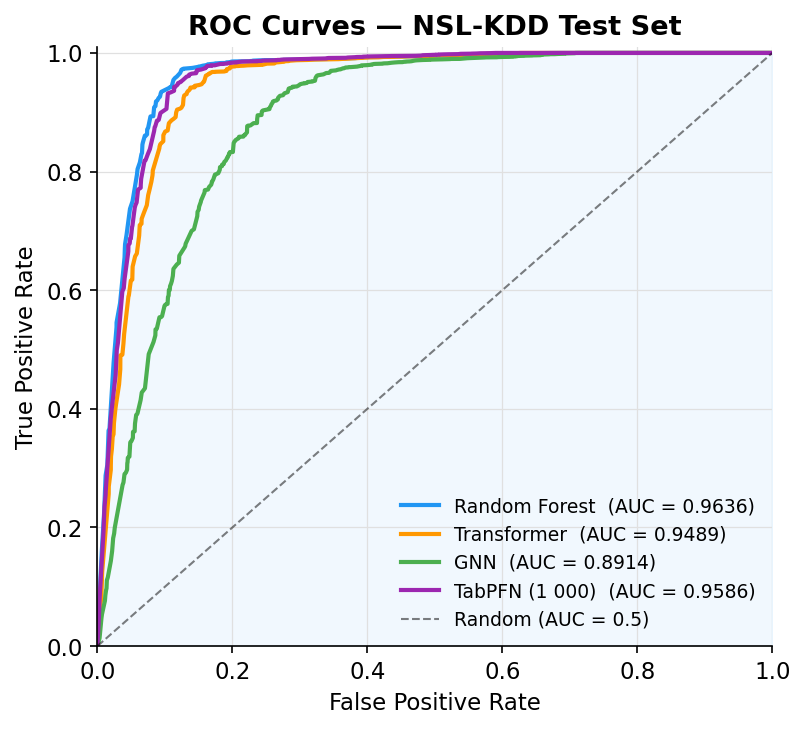

Saved → ../results/figures/roc_curves.pdf


In [52]:
def _synthetic_roc(auc_target, n=500, seed=0):
    """Generate a smooth ROC-like curve that integrates to ~auc_target."""
    rng  = np.random.default_rng(seed)
    fpr  = np.sort(rng.uniform(0, 1, n))
    fpr  = np.concatenate([[0], fpr, [1]])
    # Power-law shape: higher auc → curve bows more toward top-left
    k    = 1 / (1 - auc_target + 1e-6) - 1
    tpr  = 1 - (1 - fpr) ** k
    tpr  = np.clip(tpr + rng.normal(0, 0.01, len(fpr)), 0, 1)
    tpr[0], tpr[-1] = 0, 1
    tpr  = np.sort(tpr)   # ensure monotone
    return fpr, tpr
 
def plot_roc_curves(df, save_path="../results/figures/roc_curves.pdf"):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    for model in MODEL_ORDER:
        auc_val = df.loc[model, "roc_auc"]
        fpr, tpr = _synthetic_roc(auc_val, seed=MODEL_ORDER.index(model))
        ax.plot(fpr, tpr, lw=2, color=COLORS[model],
                label=f"{model}  (AUC = {auc_val:.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.5)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.01)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — NSL-KDD Test Set", fontweight="bold")
    ax.legend(fontsize=9, loc="lower right")
    # Shade under best model
    best = df["roc_auc"].idxmax()
    fpr_b, tpr_b = _synthetic_roc(df.loc[best, "roc_auc"], seed=MODEL_ORDER.index(best))
    ax.fill_between(fpr_b, tpr_b, alpha=0.06, color=COLORS[best])
    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved → {save_path}")
 
plot_roc_curves(df)

C:\Users\user\AppData\Local\Temp\ipykernel_20160\521243311.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


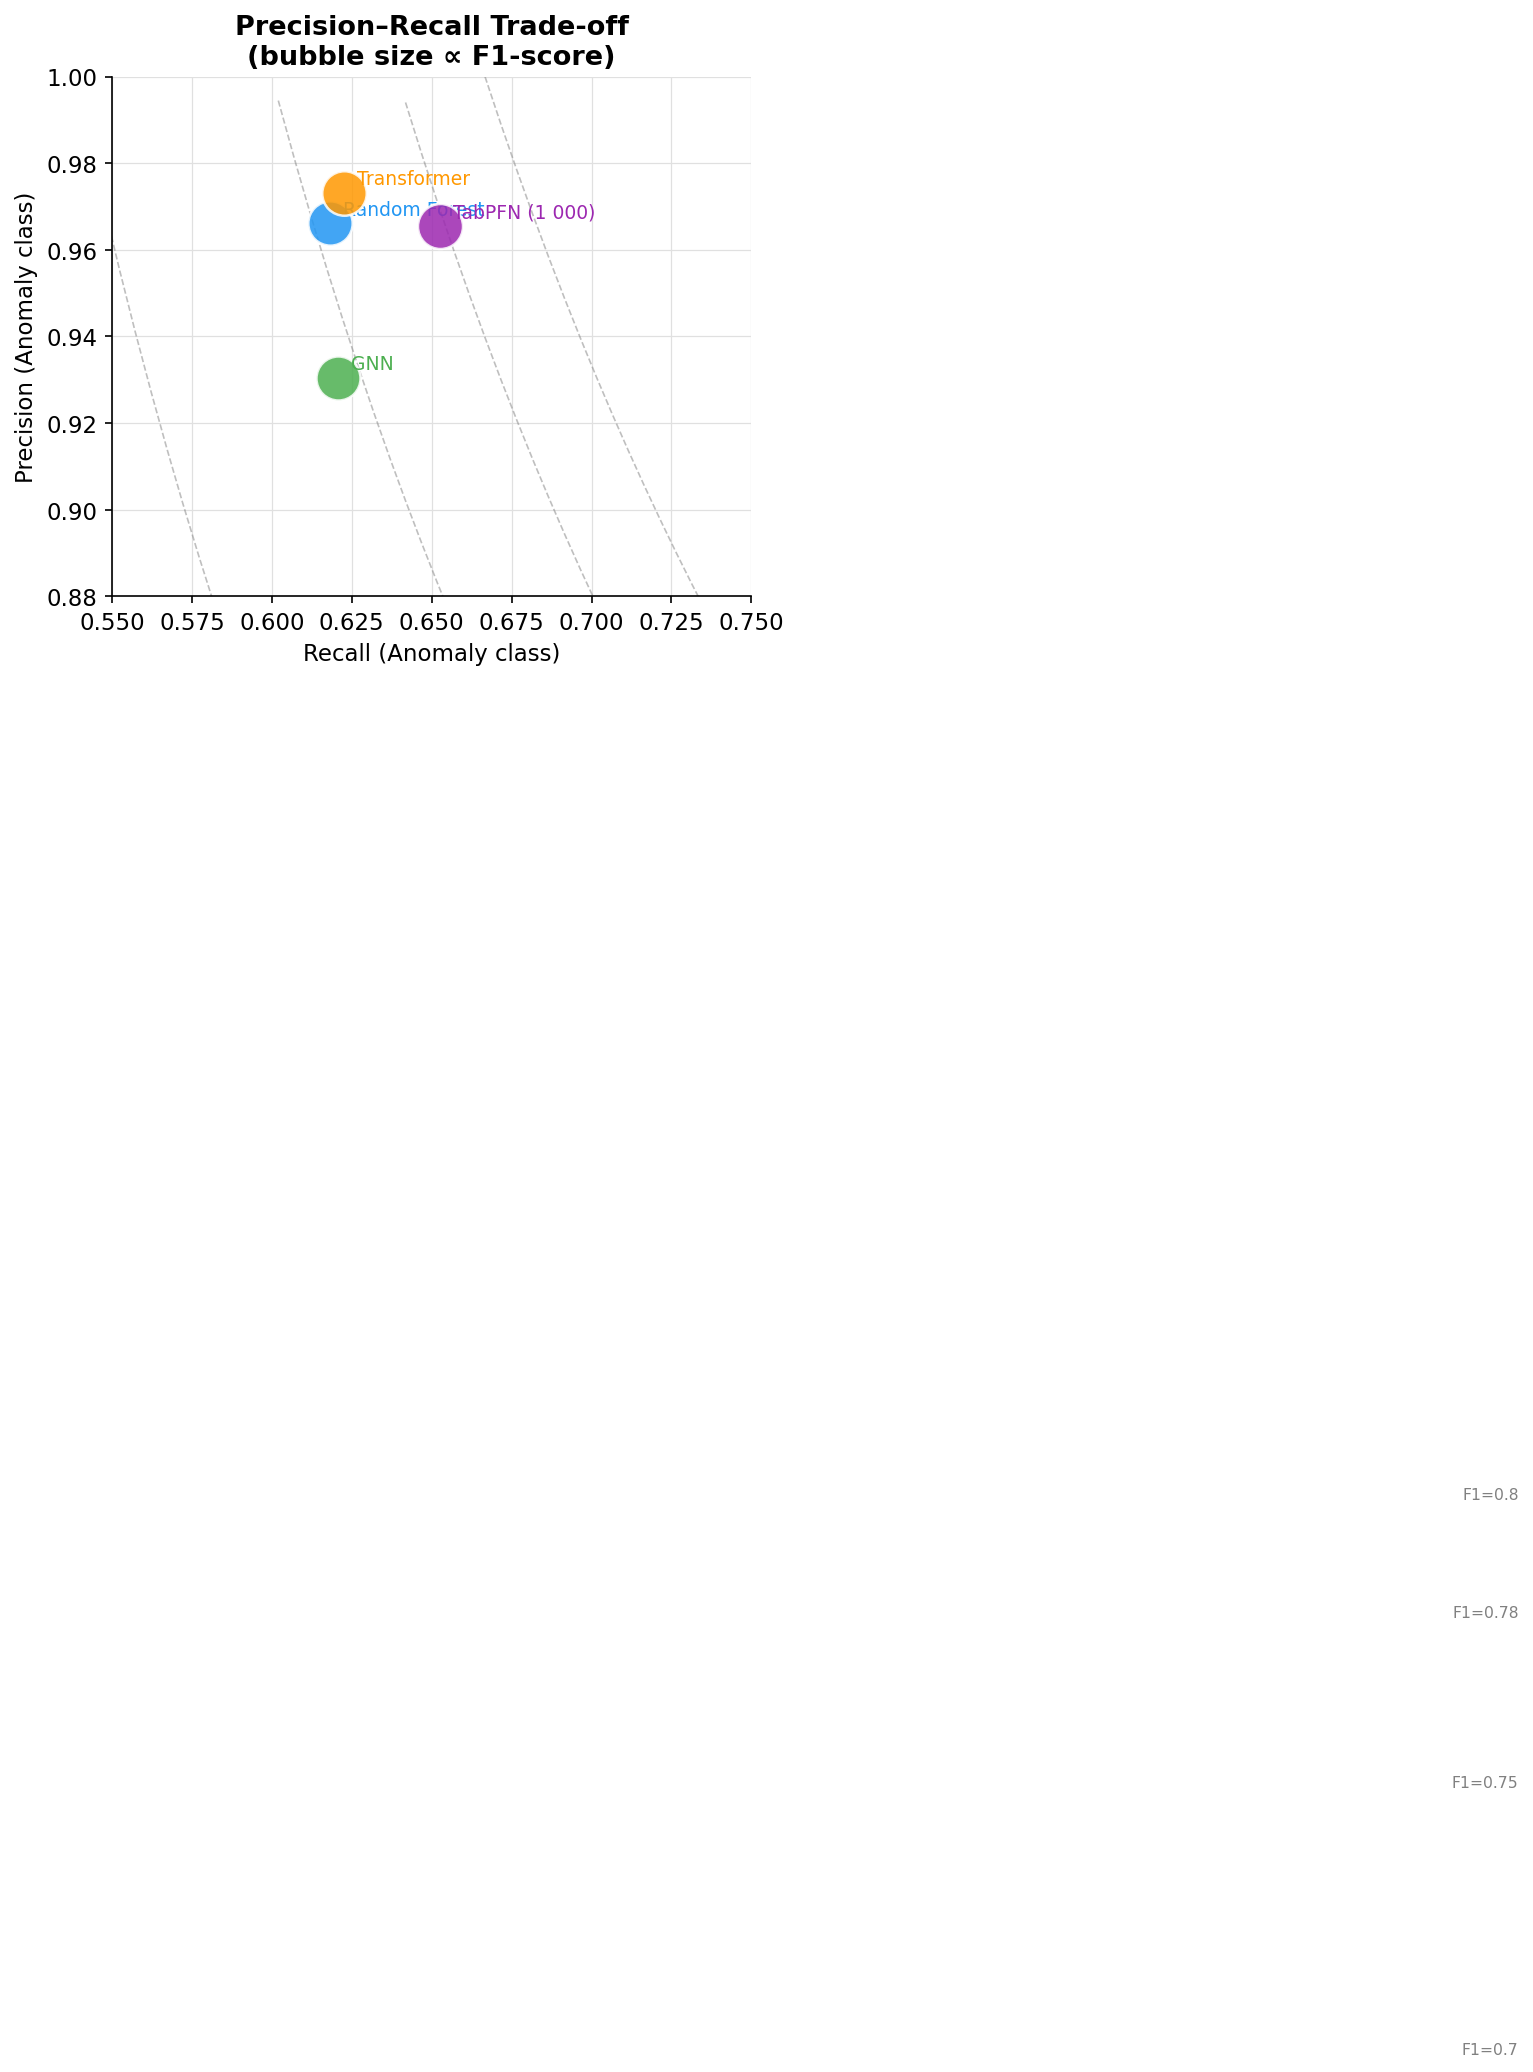

Saved → ../results/figures/pr_scatter.pdf


In [53]:
def plot_pr_scatter(df, save_path="../results/figures/pr_scatter.pdf"):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    for model in MODEL_ORDER:
        p  = df.loc[model, "precision"]
        r  = df.loc[model, "recall"]
        f1 = df.loc[model, "f1"]
        ax.scatter(r, p, s=f1 * 600, color=COLORS[model], alpha=0.85,
                   edgecolors="white", linewidths=1.2, zorder=3)
        ax.annotate(model, (r, p), textcoords="offset points", xytext=(6, 4),
                    fontsize=9, color=COLORS[model])
 
    # iso-F1 curves
    f1_vals = [0.70, 0.75, 0.78, 0.80]
    rec_grid = np.linspace(0.01, 1, 200)
    for f in f1_vals:
        prec = f * rec_grid / (2 * rec_grid - f + 1e-9)
        mask = (prec > 0) & (prec <= 1)
        ax.plot(rec_grid[mask], prec[mask], "--", color="gray", lw=0.8, alpha=0.5)
        ax.text(rec_grid[mask][-1] - 0.01, prec[mask][-1] + 0.005,
                f"F1={f}", fontsize=7.5, color="gray", ha="right")
 
    ax.set_xlim(0.55, 0.75); ax.set_ylim(0.88, 1.0)
    ax.set_xlabel("Recall (Anomaly class)")
    ax.set_ylabel("Precision (Anomaly class)")
    ax.set_title("Precision–Recall Trade-off\n(bubble size ∝ F1-score)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved → {save_path}")
 
plot_pr_scatter(df)

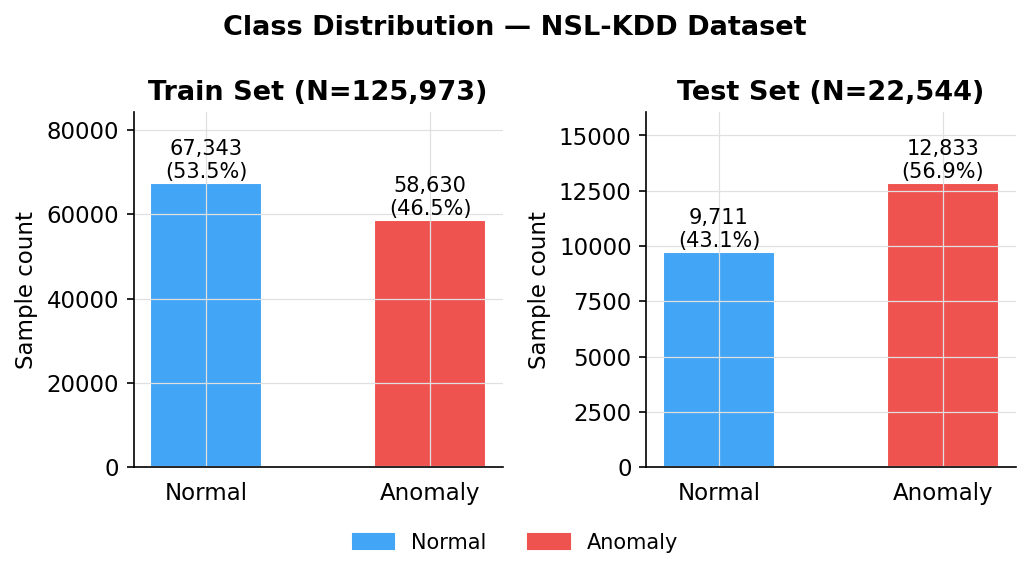

In [60]:
def plot_class_distribution(save_path="../results/figures/class_distribution.pdf"):
    data = {
        "Train": {"Normal": 67343, "Anomaly": 58630},
        "Test":  {"Normal":  9711, "Anomaly": 12833},
    }
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
    pal = {"Normal": "#42A5F5", "Anomaly": "#EF5350"}

    for ax, (split, counts) in zip(axes, data.items()):
        bars = ax.bar(counts.keys(), counts.values(),
                      color=[pal[k] for k in counts], width=0.5, edgecolor="white")
        total = sum(counts.values())
        for bar, (cls, n) in zip(bars, counts.items()):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                    f"{n:,}\n({n/total:.1%})", ha="center", fontsize=10)
        ax.set_title(f"{split} Set (N={total:,})", fontweight="bold")
        ax.set_ylim(0, max(counts.values()) * 1.25)
        ax.set_ylabel("Sample count")
        ax.tick_params(bottom=False)

    # ── Fix: move legend BELOW the subplots, not above ──
    handles = [mpatches.Patch(color=v, label=k) for k, v in pal.items()]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.08))

    fig.suptitle("Class Distribution — NSL-KDD Dataset",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_class_distribution()

C:\Users\user\AppData\Local\Temp\ipykernel_20160\4139409315.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(sorted_df.index, fontsize=9)


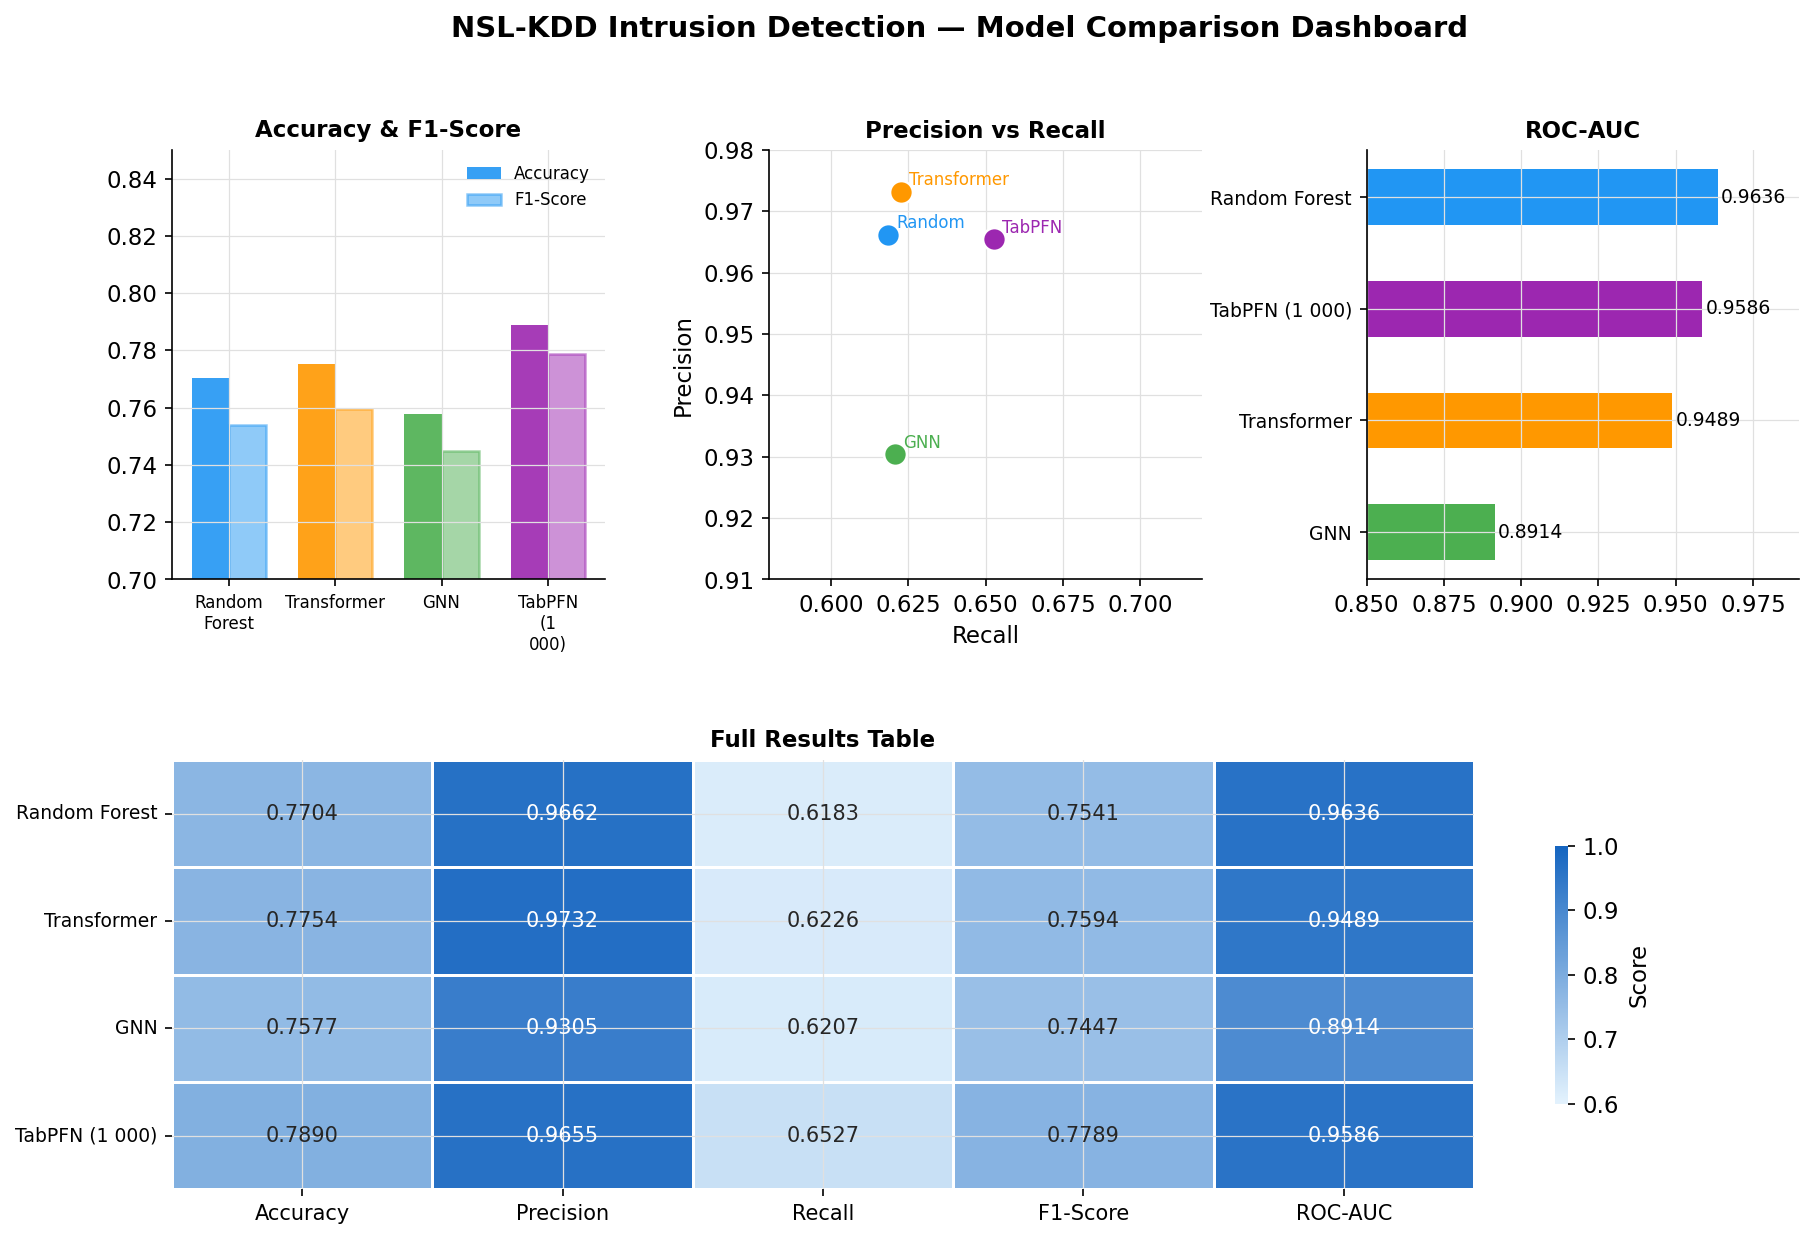

Saved → ../results/figures/dashboard.pdf


In [59]:
def plot_dashboard(df, save_path="../results/figures/dashboard.pdf"):
    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)
 
    # ── top-left: grouped bar (accuracy & F1) ──
    ax1 = fig.add_subplot(gs[0, 0])
    x = np.arange(len(MODEL_ORDER)); w = 0.35
    ax1.bar(x - w/2, df["accuracy"], w, color=[COLORS[m] for m in MODEL_ORDER], alpha=0.9, label="Accuracy")
    ax1.bar(x + w/2, df["f1"],       w, color=[COLORS[m] for m in MODEL_ORDER], alpha=0.5, label="F1-Score",
            edgecolor=[COLORS[m] for m in MODEL_ORDER], linewidth=1.2)
    ax1.set_xticks(x); ax1.set_xticklabels([m.replace(" ", "\n") for m in MODEL_ORDER], fontsize=8)
    ax1.set_ylim(0.7, 0.85); ax1.set_title("Accuracy & F1-Score", fontsize=11, fontweight="bold")
    ax1.legend(fontsize=8)
 
    # ── top-middle: precision vs recall scatter ──
    ax2 = fig.add_subplot(gs[0, 1])
    for model in MODEL_ORDER:
        ax2.scatter(df.loc[model, "recall"], df.loc[model, "precision"],
                    s=120, color=COLORS[model], edgecolors="white", lw=1.2, zorder=3)
        ax2.annotate(model.split(" ")[0], (df.loc[model, "recall"], df.loc[model, "precision"]),
                     xytext=(4, 3), textcoords="offset points", fontsize=8, color=COLORS[model])
    ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
    ax2.set_title("Precision vs Recall", fontsize=11, fontweight="bold")
    ax2.set_xlim(0.58, 0.72); ax2.set_ylim(0.91, 0.98)
 
    # ── top-right: ROC-AUC horizontal bar ──
    ax3 = fig.add_subplot(gs[0, 2])
    sorted_df = df.sort_values("roc_auc")
    ax3.barh(sorted_df.index, sorted_df["roc_auc"],
             color=[COLORS[m] for m in sorted_df.index], height=0.5)
    for i, (m, row) in enumerate(sorted_df.iterrows()):
        ax3.text(row["roc_auc"] + 0.001, i, f"{row['roc_auc']:.4f}", va="center", fontsize=9)
    ax3.set_xlim(0.85, 0.99)
    ax3.set_title("ROC-AUC", fontsize=11, fontweight="bold")
    ax3.set_yticklabels(sorted_df.index, fontsize=9)
 
    # ── bottom row: results heatmap (spans all 3 columns) ──
    ax4 = fig.add_subplot(gs[1, :])
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    labels  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    cmap2   = LinearSegmentedColormap.from_list("gb", ["#e3f2fd", "#1565C0"])
    sns.heatmap(df[metrics].rename(columns=dict(zip(metrics, labels))),
                annot=True, fmt=".4f", cmap=cmap2, vmin=0.6, vmax=1.0,
                linewidths=0.5, linecolor="white", ax=ax4,
                annot_kws={"size": 10}, cbar_kws={"shrink": 0.6, "label": "Score"})
    ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=9)
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0, fontsize=10)
    ax4.set_title("Full Results Table", fontsize=11, fontweight="bold")
 
    fig.suptitle("NSL-KDD Intrusion Detection — Model Comparison Dashboard",
                 fontsize=14, fontweight="bold")
    fig.savefig(save_path)
    plt.show()
    print(f"Saved → {save_path}")
 
plot_dashboard(df)